/kaggle/input/competitions/home-data-for-ml-course/sample_submission.csv
/kaggle/input/competitions/home-data-for-ml-course/sample_submission.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/train.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/data_description.txt
/kaggle/input/competitions/home-data-for-ml-course/test.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/train.csv
/kaggle/input/competitions/home-data-for-ml-course/test.csv
(1460, 84)
Missing val count by column
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64
Num of unique entries by column
[('Street', 2), ('Alley', 2), ('Utilities', 2), 

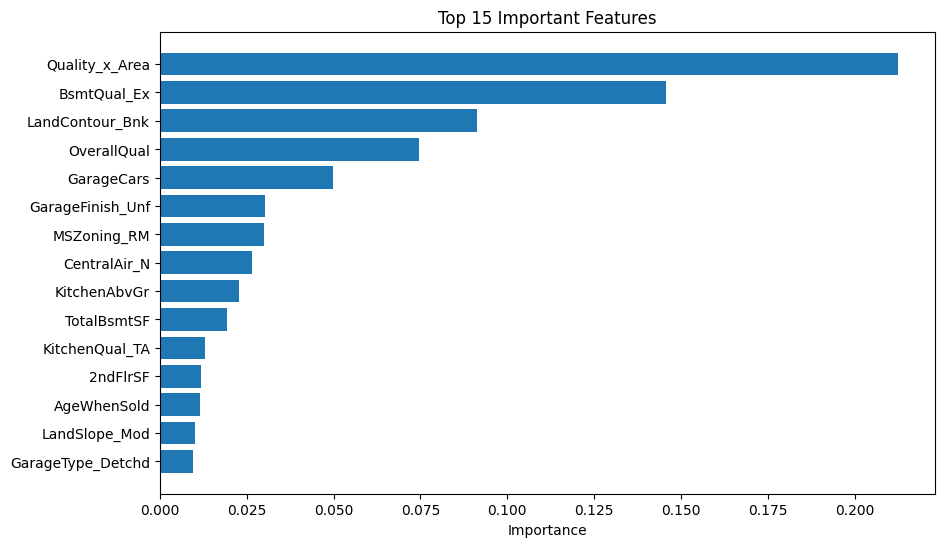

In [1]:
## This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# import libraries 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from xgboost import XGBRegressor


# Load and create the data
train_csv = '/kaggle/input/competitions/home-data-for-ml-course/train.csv'
train_data = pd.read_csv(train_csv)
test_csv = '/kaggle/input/competitions/home-data-for-ml-course/test.csv'
test_data = pd.read_csv(test_csv)

# Create new columns
train_data['TotalBath'] = train_data['FullBath'] + (0.5 * train_data['HalfBath'])
test_data['TotalBath'] = test_data['FullBath'] + (0.5 * test_data['HalfBath'])
train_data['Bsmnt_to_Living_Ratio'] = train_data['TotalBsmtSF'] / train_data['GrLivArea']
test_data['Bsmnt_to_Living_Ratio'] = test_data['TotalBsmtSF'] / test_data['GrLivArea']
train_data['Quality_x_Area'] = train_data['OverallQual'] * train_data['GrLivArea']
test_data['Quality_x_Area'] = test_data['OverallQual'] * test_data['GrLivArea']
train_data['AgeWhenSold'] = train_data['YrSold'] - train_data['YearBuilt']
test_data['AgeWhenSold'] = test_data['YrSold'] - test_data['YearBuilt']


# Create y and X
# Remove rows with missing target, separate target from predictors
train_data.dropna(axis=0, subset=['SalePrice'], inplace=True)
y = train_data.SalePrice
X = train_data.drop(['SalePrice'], axis=1)

# Split into validation and training data
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=1)

# =================== Preproccessing =========================

# --- Data exploration for null values ---
# Shape of training data (num_rows, num_columns)
print(X.shape)
# Number of missing values in each column of training data
missing_val_count_by_column =  (X.isnull().sum())
print(f'Missing val count by column\n{missing_val_count_by_column[missing_val_count_by_column > 0]}')

# --- Data exploration for number of unique entries ---

# Select categorical columns with relatively low cardinality (convenient but arbitrary)
categorical_cols = [cname for cname in X.columns if X[cname].dtype == "object"]

# Select numerical columns
numerical_cols = [cname for cname in X.columns if 
                X[cname].dtype in ['int64', 'float64']]

# Get number of unique entries in each column with categorical data
categorical_nunique = list(map(lambda col: X[col].nunique(), categorical_cols))
d = dict(zip(categorical_cols, categorical_nunique))
# Print number of unique entries by column, in ascending order
print(f'Num of unique entries by column\n{sorted(d.items(), key=lambda x: x[1])}')

# --- Drop columns containing many null values (>20%) ---
missing_pct = X.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.20].index.tolist()
numerical_cols = [c for c in numerical_cols if c not in cols_to_drop]
categorical_cols = [c for c in categorical_cols if c not in cols_to_drop]

# Select low cardinality columns (< 10 unique values)
low_cardinality_cols = [cname for cname in categorical_cols if 
                        X[cname].nunique() < 10]

# Select high cardinality columns (>= 10 unique values)
high_cardinality_cols = [cname for cname in categorical_cols if 
                         X[cname].nunique() >= 10]

        
# Keep selected columns only
my_cols = low_cardinality_cols + high_cardinality_cols + numerical_cols
X_final = X[my_cols].copy()
X_test = test_data[my_cols].copy()


# ----------- Transforming --------------

# Transforming for numerical data
numerical_transformer = SimpleImputer(strategy='median') # Your code here

# Transforming for OneHot
oh_transformer = categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Transforming for Ordinal (High Cardinality)
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Compose all in ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('oh', oh_transformer, low_cardinality_cols),
        ('ord', ordinal_transformer, high_cardinality_cols)
    ])


# ========== Define model==============

#def get_score(max_depth):
#    gs_pipeline = Pipeline(steps=[
#        ('preprocessor', preprocessor),
#        ('model', RandomForestRegressor(n_estimators=250, max_depth=max_depth, random_state=0))
#    ])
#    scores = -1 * cross_val_score(gs_pipeline, X_final, y, cv=5, scoring='neg_mean_absolute_error')
#    return scores.mean()

#results = {n: get_score(n) for n in [5, 10, 15, 20, 25, 30, 35, None]}

#%matplotlib inline
#plt.plot(list(results.keys()), list(results.values()))
#plt.show()


# ========== Define XGBoost model==============
# Preproccessing
#X_train_prepped = preprocessor.fit_transform(X_train)
#X_val_prepped = preprocessor.transform(X_val)

# Define model and fit
#test_xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05, early_stopping_rounds=10, random_state=0)
#test_xgb.fit(X_train_prepped, y_train, 
#             eval_set=[(X_val_prepped, y_val)], 
#             verbose=True)
    

# ----------- Run final model ---------------
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=214, learning_rate=0.05, random_state=0))
])

# Cross validation score
scores = -1 * cross_val_score(final_pipeline, X_final, y, cv=5, scoring='neg_mean_absolute_error')
print(f"Average CV MAE: {scores.mean():,.2f}")

# Model training
final_pipeline.fit(X_final, y)


# --- Show more important columns for RandomForestRegressor
ohe_feature_names = (final_pipeline.named_steps['preprocessor']
                     .named_transformers_['oh']
                     .named_steps['onehot']
                     .get_feature_names_out(low_cardinality_cols).tolist())

feature_names = numerical_cols + ohe_feature_names + high_cardinality_cols
importances = final_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df.head(20)) # Show thw 20 more important
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:15], feature_importance_df['Importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Important Features')
plt.gca().invert_yaxis()
plt.show()

# ======== Define the model for test data ========

# Preprocessing of test data, fit model
test_preds = final_pipeline.predict(X_test)


# Save test predictions to file
output = pd.DataFrame({'Id': test_data.Id, 'SalePrice': test_preds})
output.to_csv('submission.csv', index=False)